brazilian_championship_seriesa.csv:

- Time (Club): The name of the football team participating in the tournament;
- Ano (Season): The specific year or edition of the championship (e.g., 2021, 2024, 2025);
- Classificação (Standings): The final rank or position of the team in the league table at the end of the season;
- Pontos (Points): The total number of points earned by the team (usually 3 for a win, 1 for a draw, and 0 for a loss);
- Jogos (Played): The total number of matches the team played during that season;
-  Vitórias (Wins): The number of matches won by the team;
- Empates (Draws): The number of matches that ended in a tie;
- Derrotas (Losses): The number of matches lost by the team;
- Gols Prós (Goals For): The total number of goals scored by the team.
- Gols Contras (Goals Against): The total number of goals conceded (allowed) by the team;
- Saldo de gols (Goal Difference): The net difference between goals scored and goals conceded (Goals For - Goals Against);
- Cartões Amarelos (Yellow Cards): The total number of cautions received by the team's players;
- Cartões Vermelhos (Red Cards): The total number of dismissals (ejections) received by the team's players;
- Aproveitamento (Win %): The percentage of possible points the team actually earned during the season.

0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fitz
from IPython.display import display, Image

1. Loading the dataset

Loading the dataset and displaying its information and first few rows:

In [2]:
seriesa_data = pd.read_csv('../../data/raw/brazilian_championship_seriesa.csv')
seriesa_data.info()
seriesa_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Classificação      100 non-null    int64
 1   Time               100 non-null    str  
 2   Pontos             100 non-null    int64
 3   Jogos              100 non-null    int64
 4   Vitórias           100 non-null    int64
 5   Empates            100 non-null    int64
 6   Derrotas           100 non-null    int64
 7   Gols Prós          100 non-null    int64
 8   Gols Contras       100 non-null    int64
 9   Saldos de Gols     100 non-null    int64
 10  Cartões Amarelos   100 non-null    int64
 11  Cartões Vermelhos  100 non-null    int64
 12  Aproveitamento     100 non-null    int64
 13  Ano                100 non-null    int64
dtypes: int64(13), str(1)
memory usage: 11.1 KB


,Classificação,Time,Pontos,Jogos,Vitórias,Empates,Derrotas,Gols Prós,Gols Contras,Saldos de Gols,Cartões Amarelos,Cartões Vermelhos,Aproveitamento,Ano
0,1,Atlético Mineiro Saf,84,38,26,6,6,67,34,33,82,4,73,2021
1,2,Flamengo,71,38,21,8,9,69,36,33,82,4,62,2021
2,3,Palmeiras,66,38,20,6,12,58,43,15,87,11,57,2021
3,4,Fortaleza Ec Saf,58,38,17,7,14,44,45,-1,95,7,50,2021
4,5,Corinthians,57,38,15,12,11,40,36,4,61,3,50,2021


2. Data preprocessing

2.1. Checking for outliers in the columns:

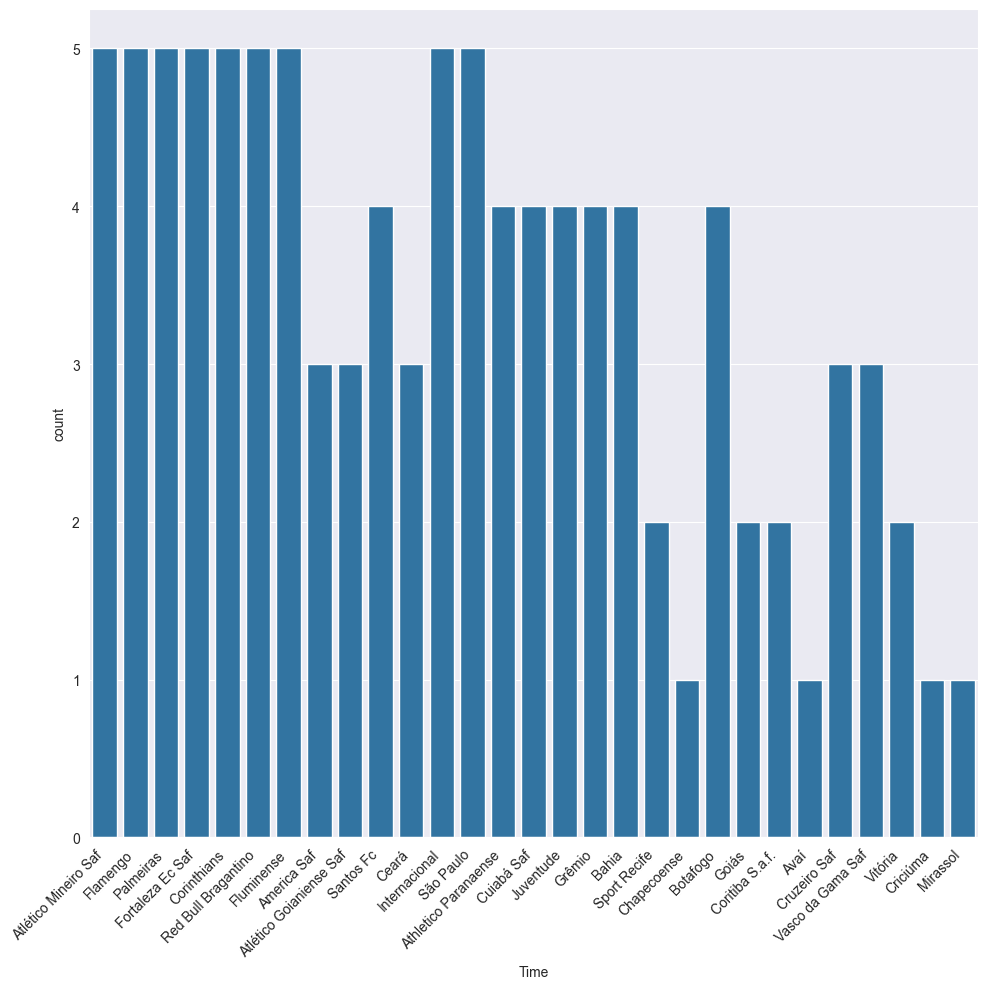

In [3]:
sns.set_style("darkgrid")
plt.figure(figsize=(10, 10))

sns.countplot(x=seriesa_data['Time'])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

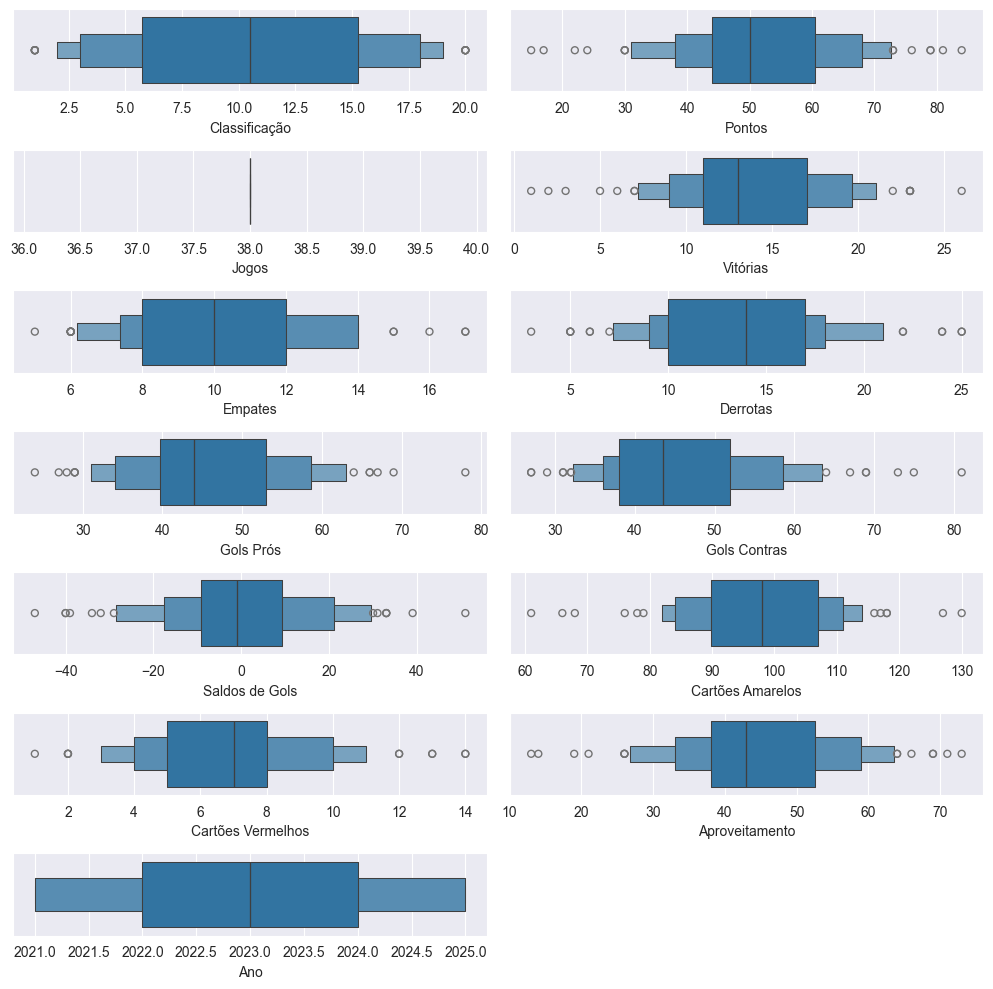

In [4]:
sns.set_style("darkgrid")
plt.figure(figsize=(10, 10))

cols = ['Classificação', 'Pontos', 'Jogos', 'Vitórias', 'Empates', 'Derrotas', 'Gols Prós', 'Gols Contras', 'Saldos de Gols', 'Cartões Amarelos', 'Cartões Vermelhos', 'Aproveitamento', 'Ano']
for i in range(13):
    plt.subplot(7, 2, i+1)
    sns.boxenplot(x=seriesa_data[cols[i]])

plt.tight_layout()

The outliers in the columns are all relevant to the analysis and are not unrealistic values, therefore I did not remove them.

2.2. Exploring the basic statistics of the "Aproveitamento" (Win %) column (Checking if there is any data that is not well represented by the average, considering the plotting):

In [5]:
resume_num = seriesa_data.groupby('Ano')['Aproveitamento'].describe()
resume_num['cv'] = (resume_num['std']/resume_num['mean'])*100
resume_num

,count,mean,std,min,25%,50%,75%,max,cv
Ano,,,,,,,,,
2021,20.0,44.60,11.842830,13.0,40.75,43.0,49.25,73.0,26.553431
2022,20.0,44.80,12.812823,19.0,35.75,46.0,51.00,71.0,28.600050
2023,20.0,45.25,10.852480,21.0,38.75,46.5,54.50,61.0,23.983381
2024,20.0,45.15,11.952868,26.0,38.75,42.0,52.50,69.0,26.473683
2025,20.0,45.15,12.990989,14.0,38.75,42.0,55.25,69.0,28.772954


All years have an acceptable average.

3. Data Mining:

(Charts plotted in Power BI Desktop)

3.1. Performing Multivariate Analysis:




Time (Club) x Classificação (Standings) x Ano (Season):


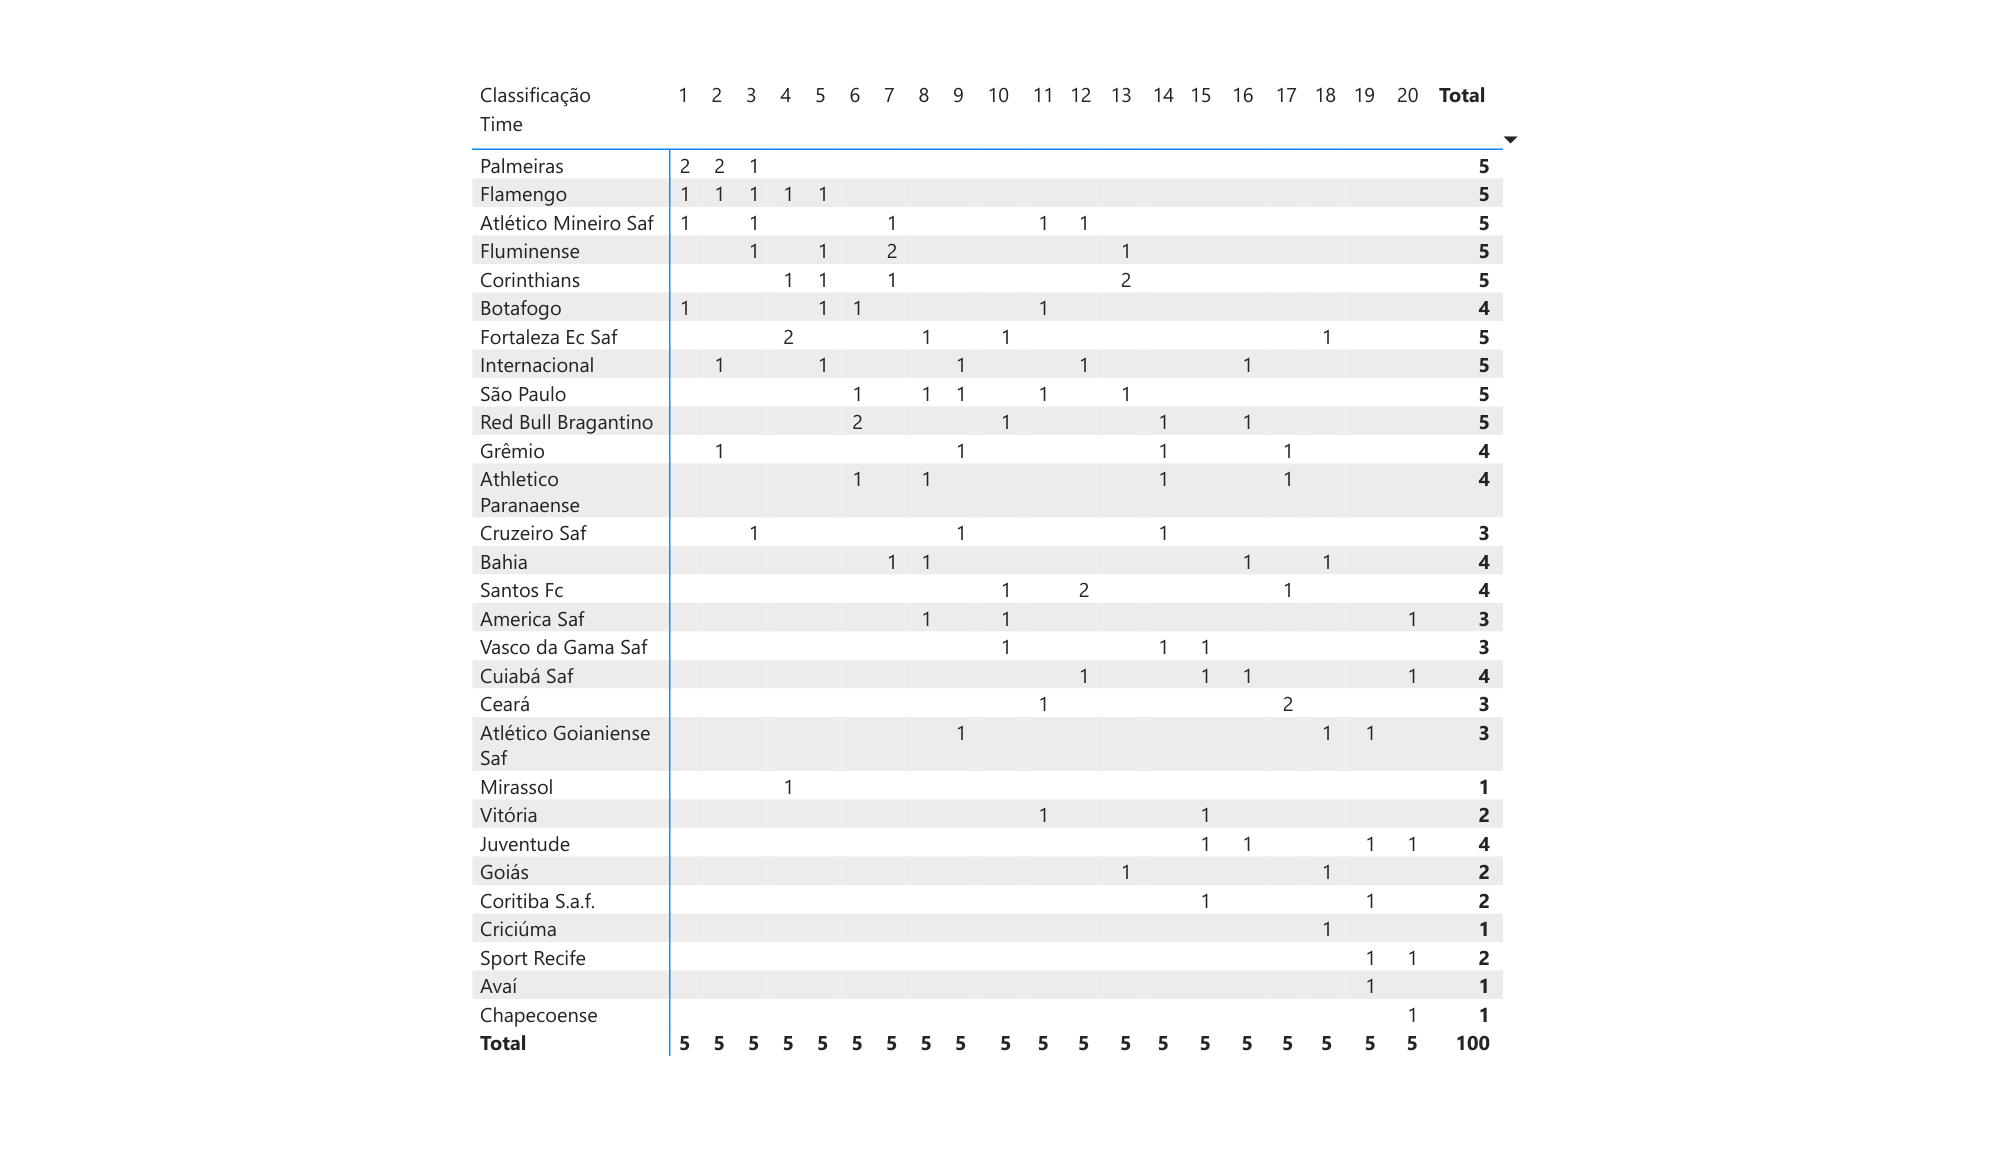

Time (Club) x Pontos (Points) x Ano (Season):


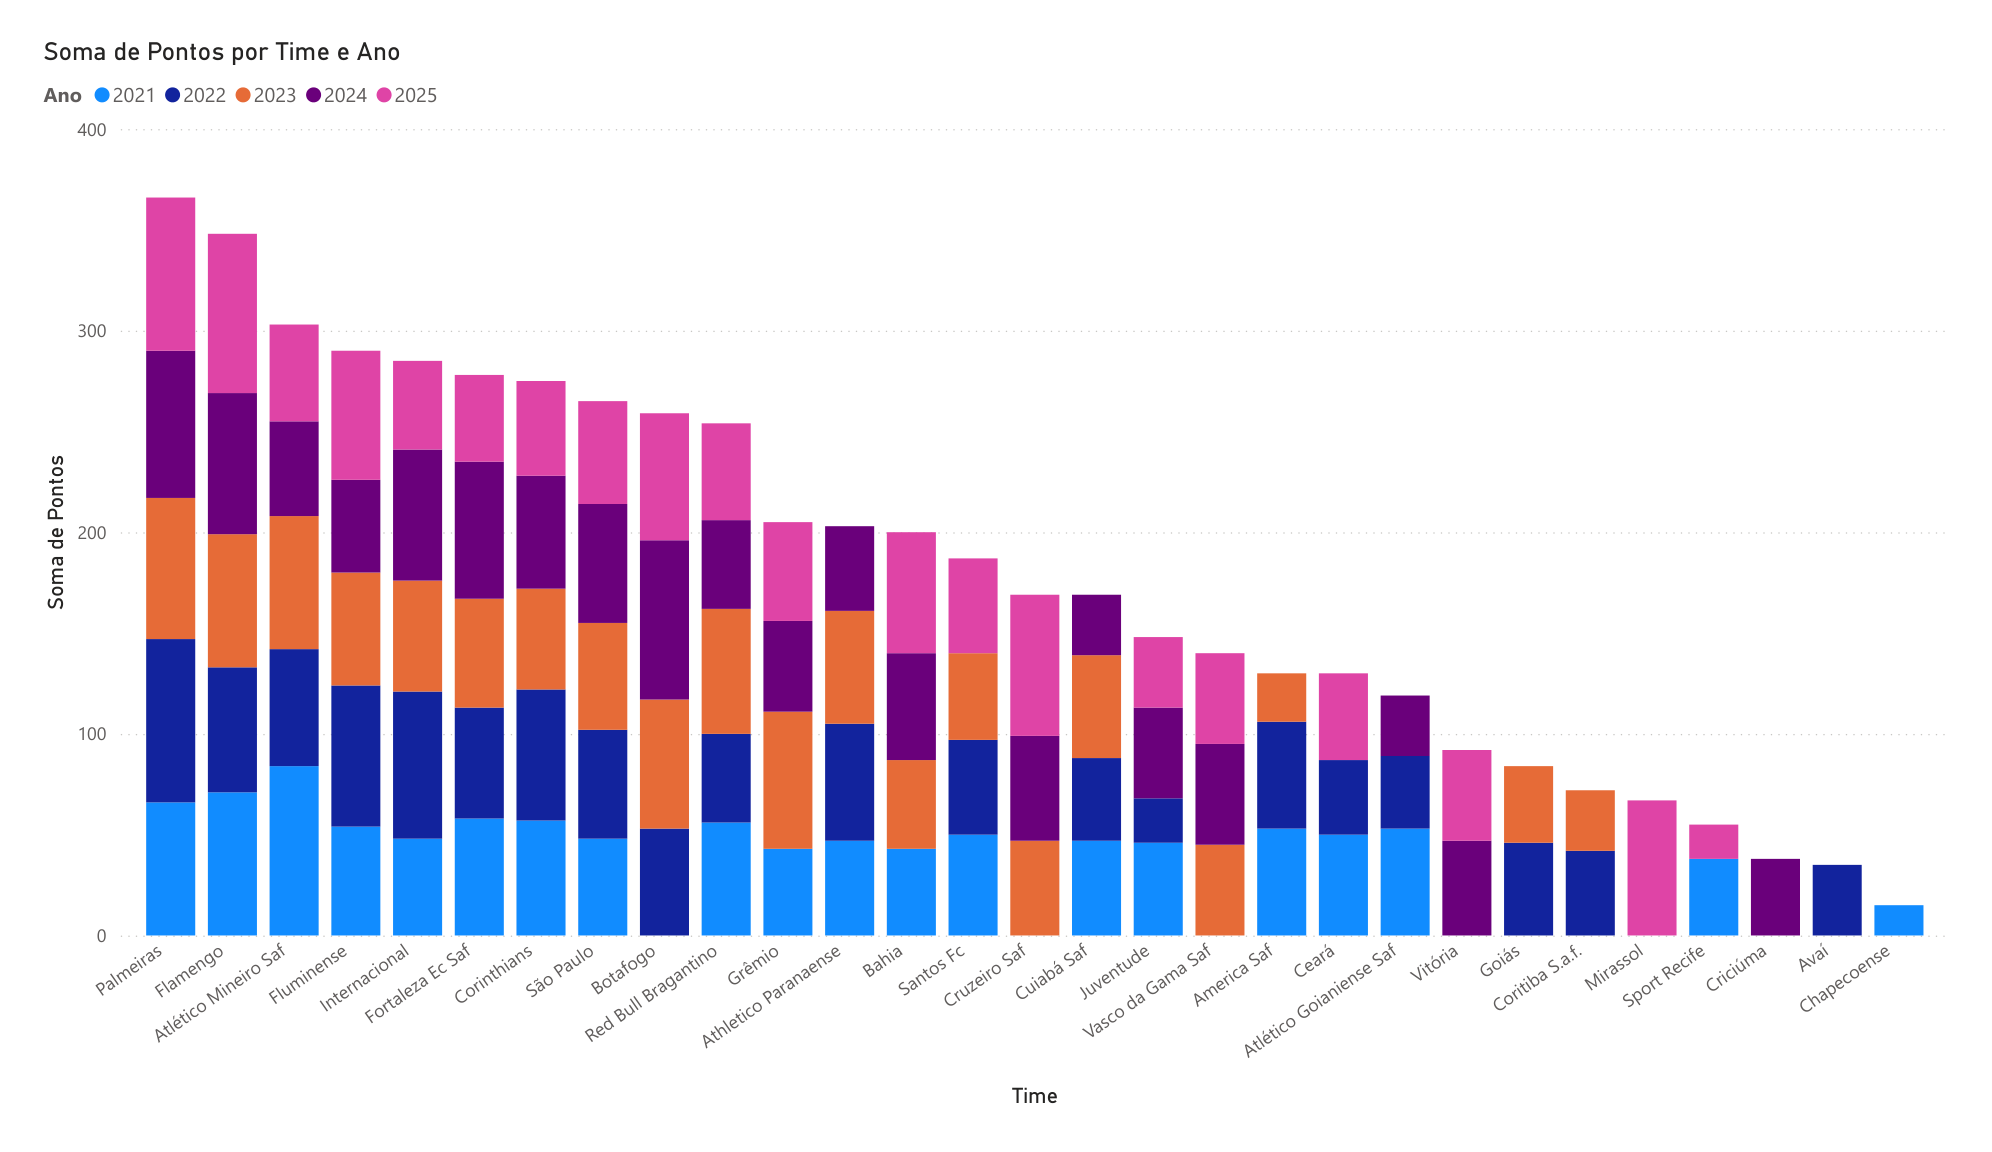

Time (Club) x Jogos (Played) x Ano (Season):


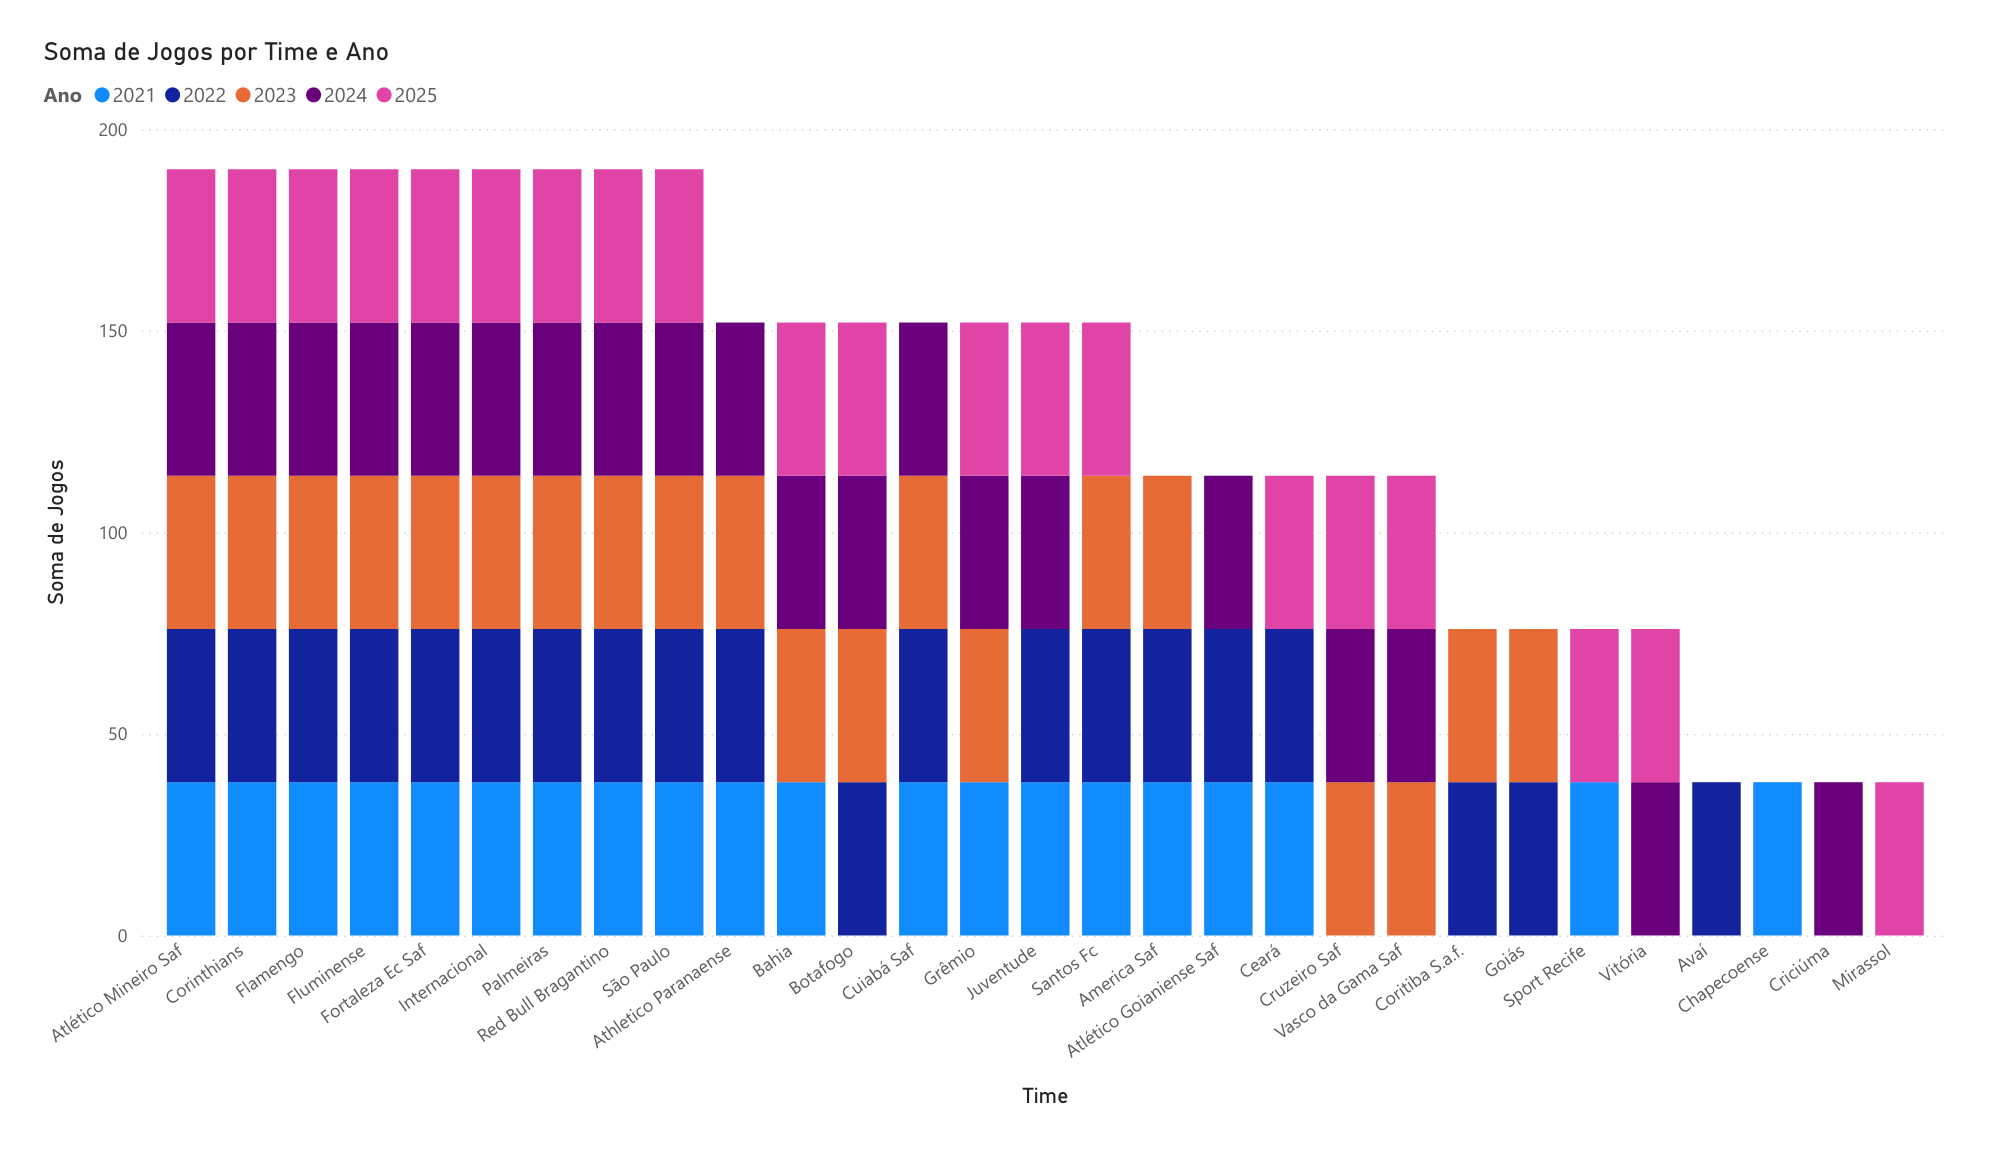

Time (Club) x Vitórias (Wins) x Ano (Season):


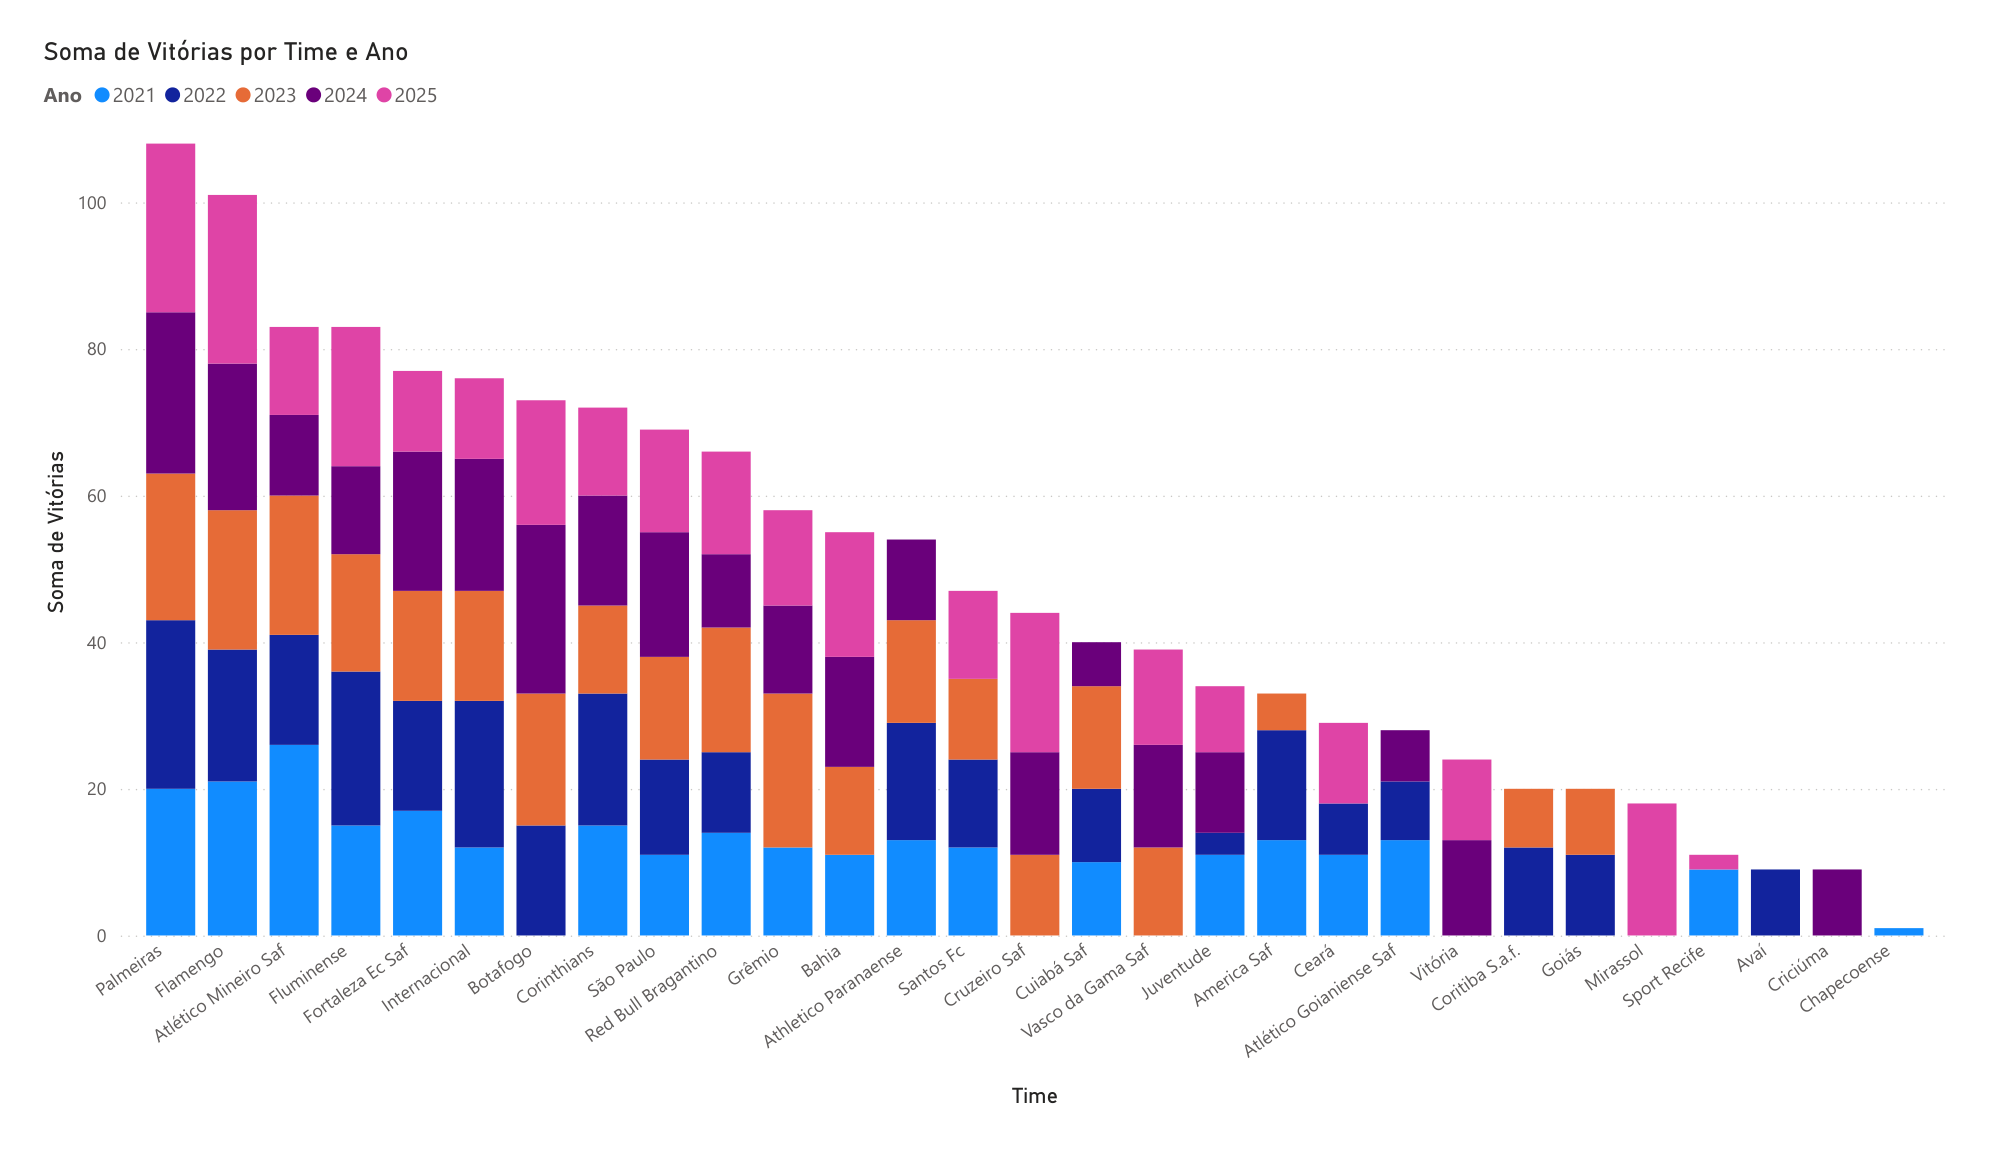

Time (Club) x Empates (Draws) x Ano (Season):


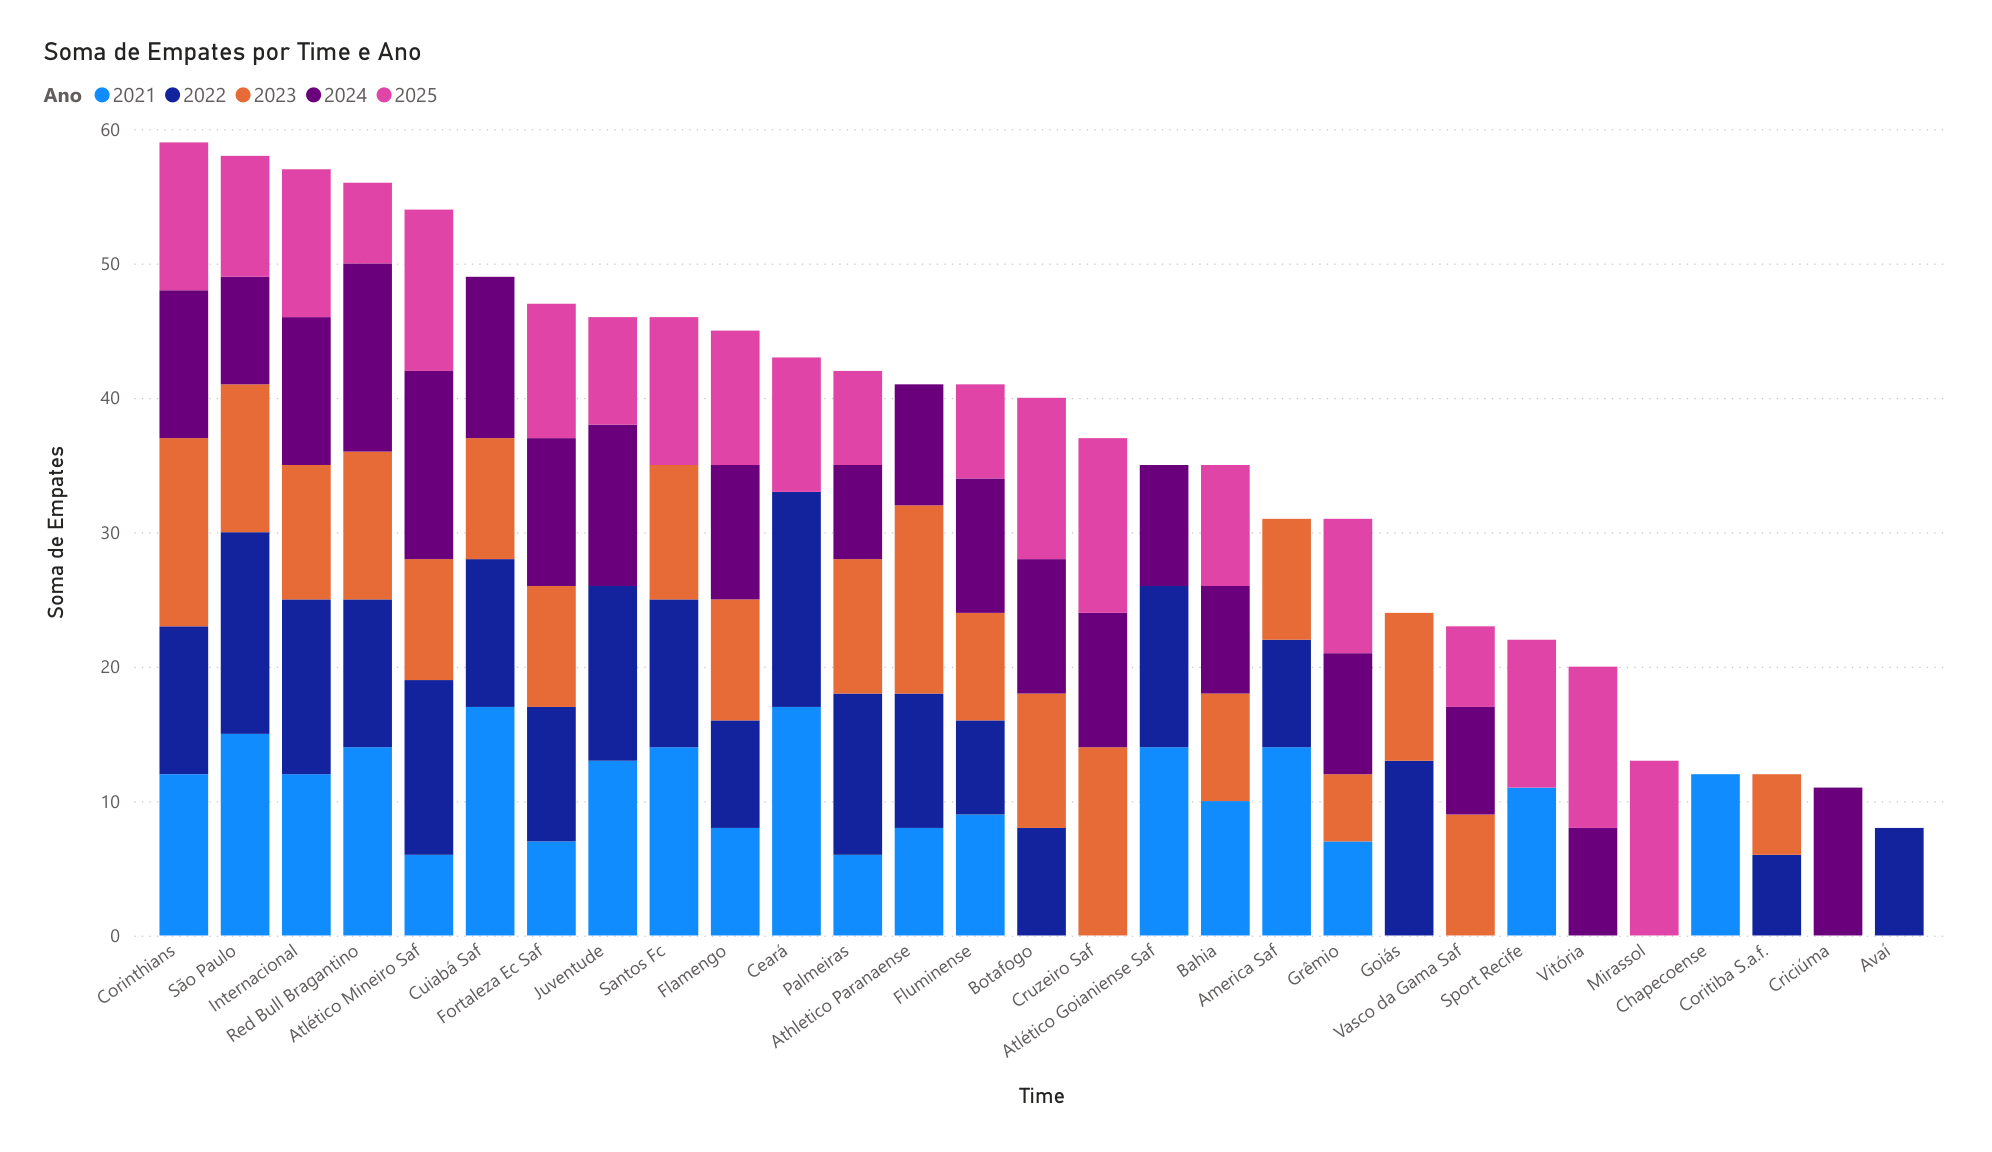

Time (Club) x Derrotas (Losses) x Ano (Season):


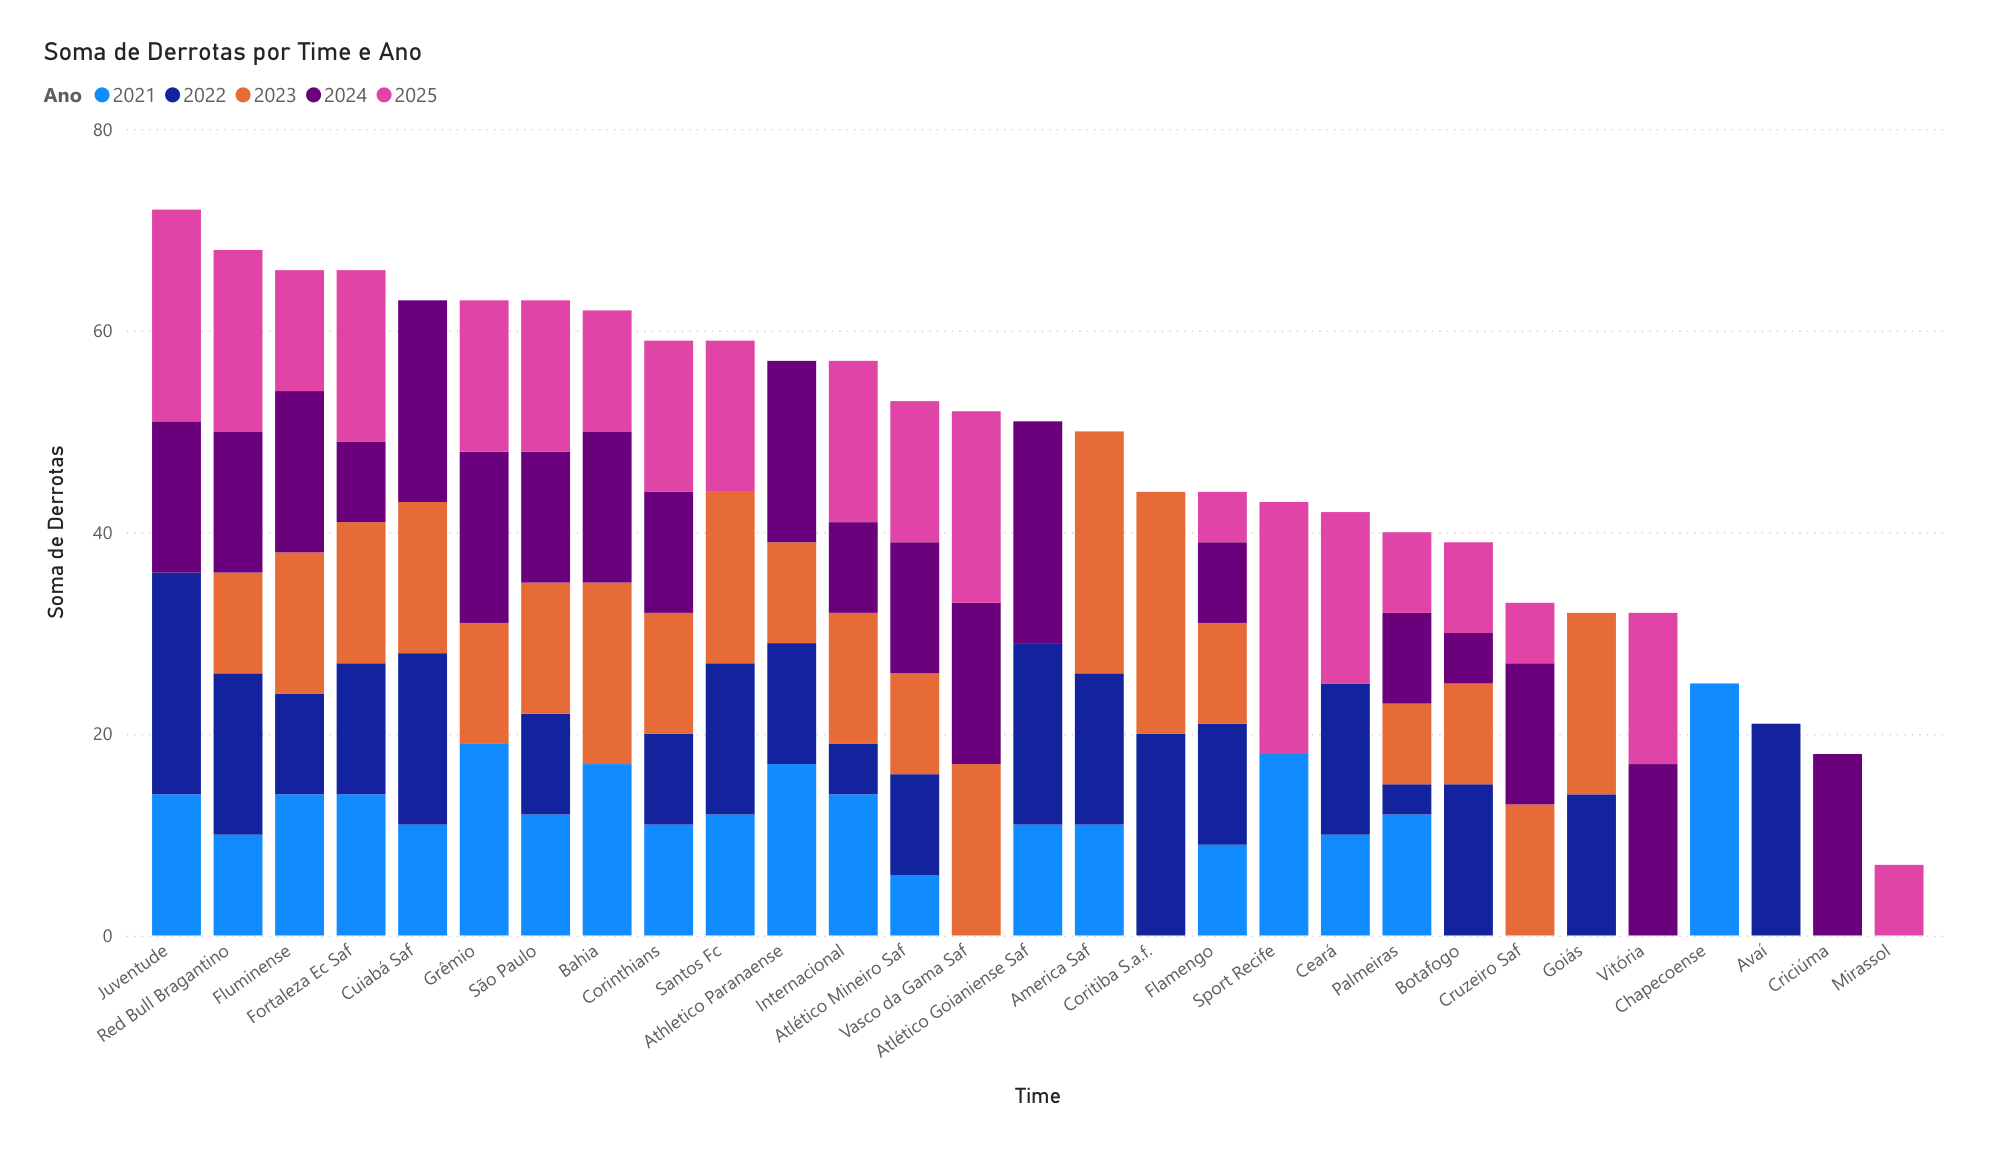

Time (Club) x Gols Prós (Goals For) x Ano (Season):


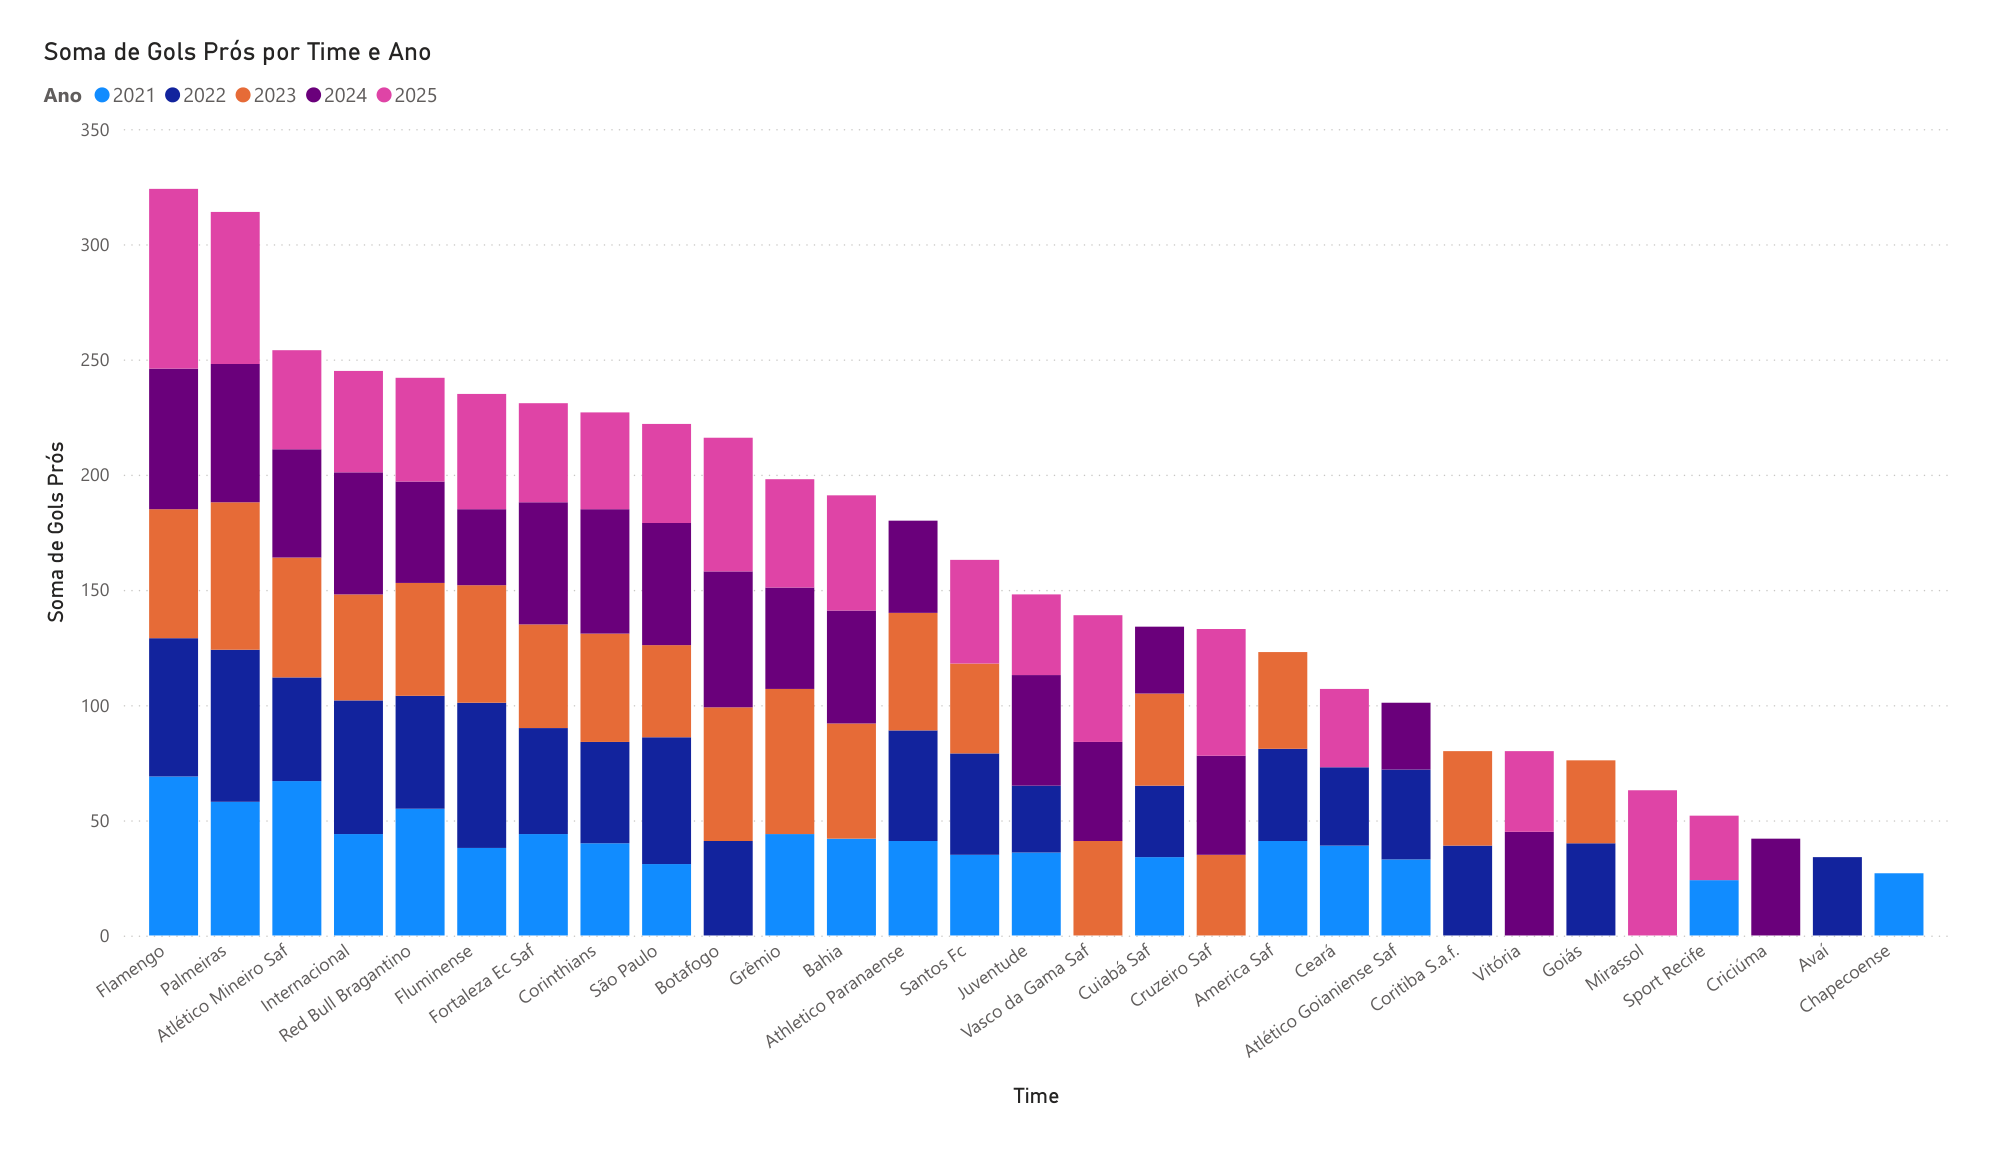

Time (Club) x Gols Contras (Goals Against) x Ano (Season):


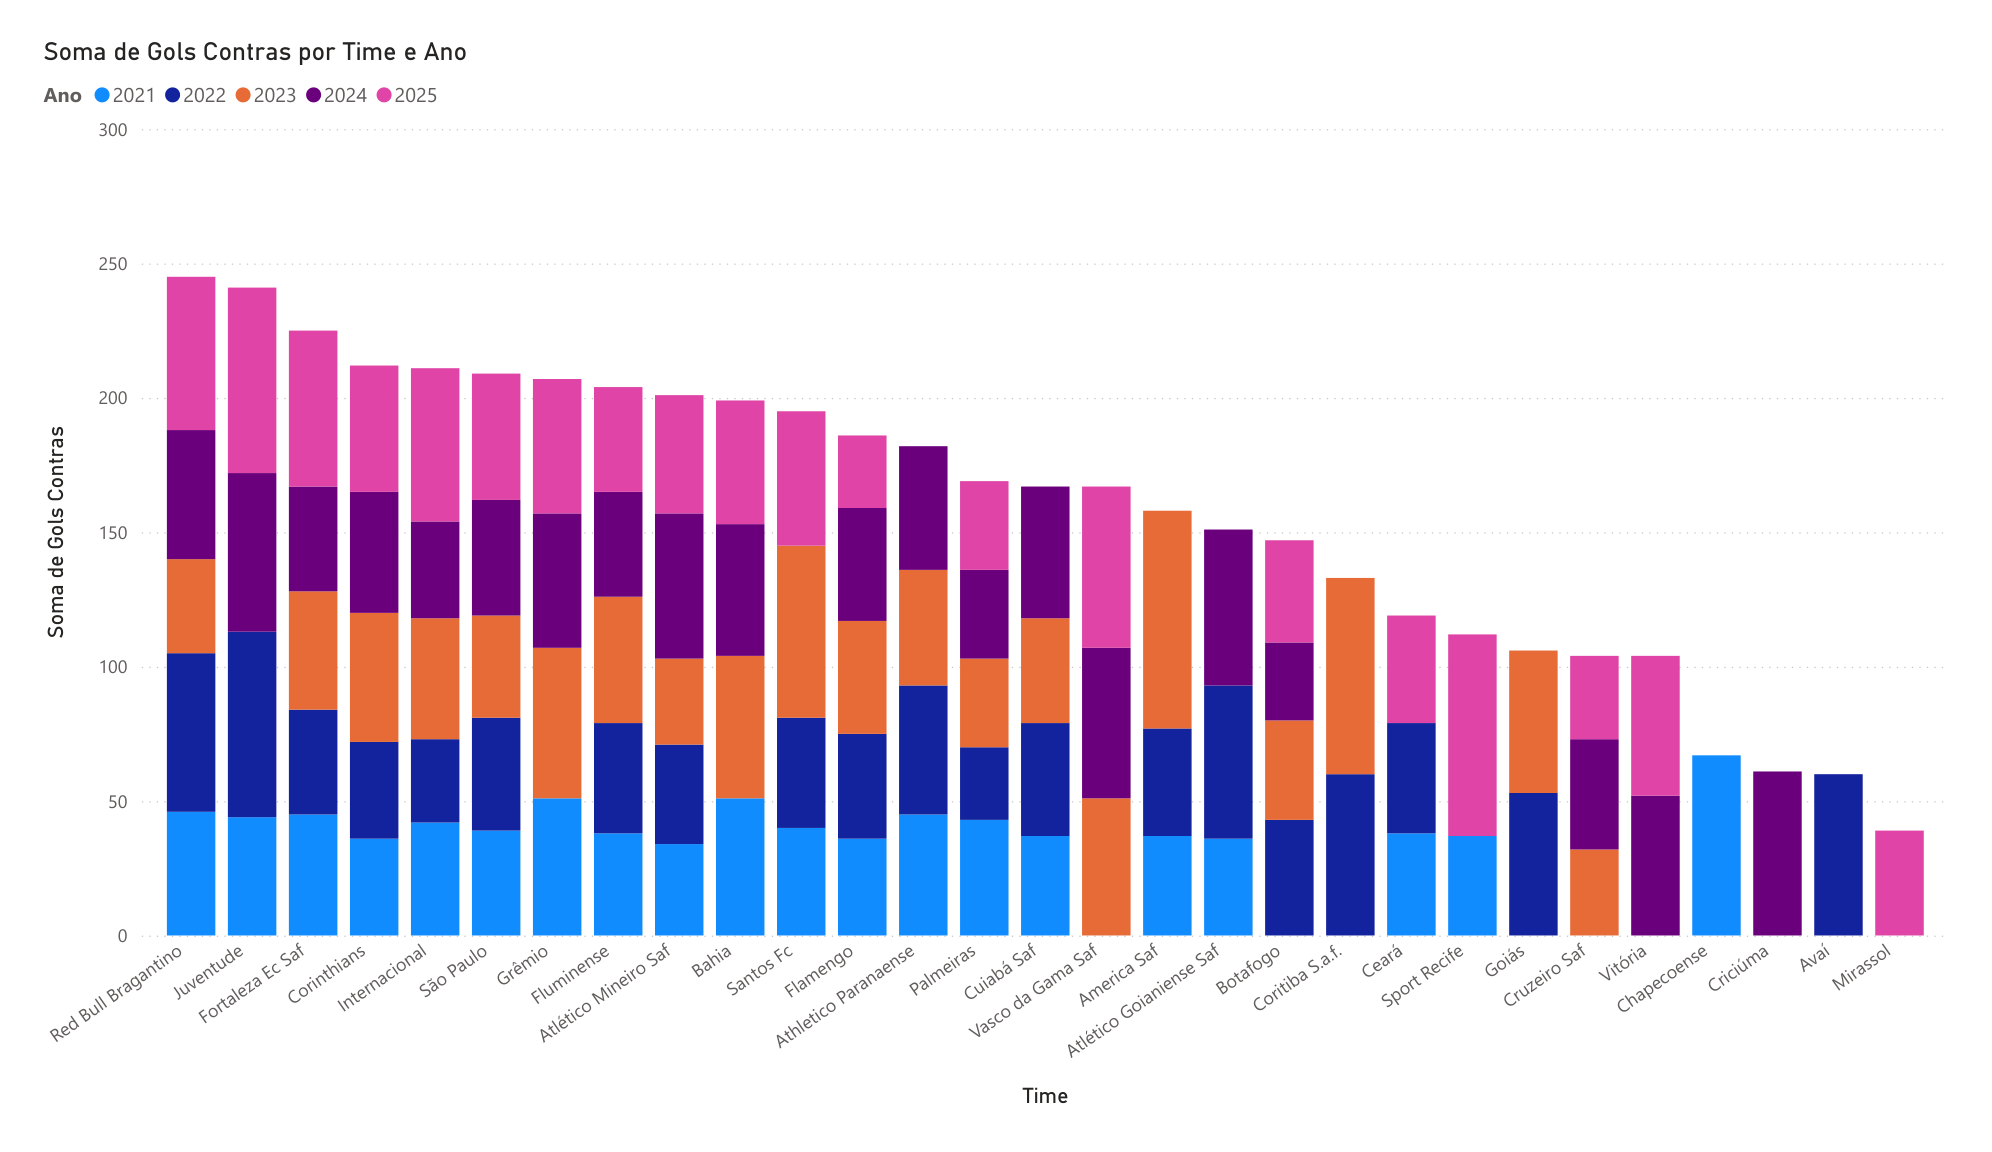

Time (Club) x Saldo de gols (Goal Difference) x Ano (Season):


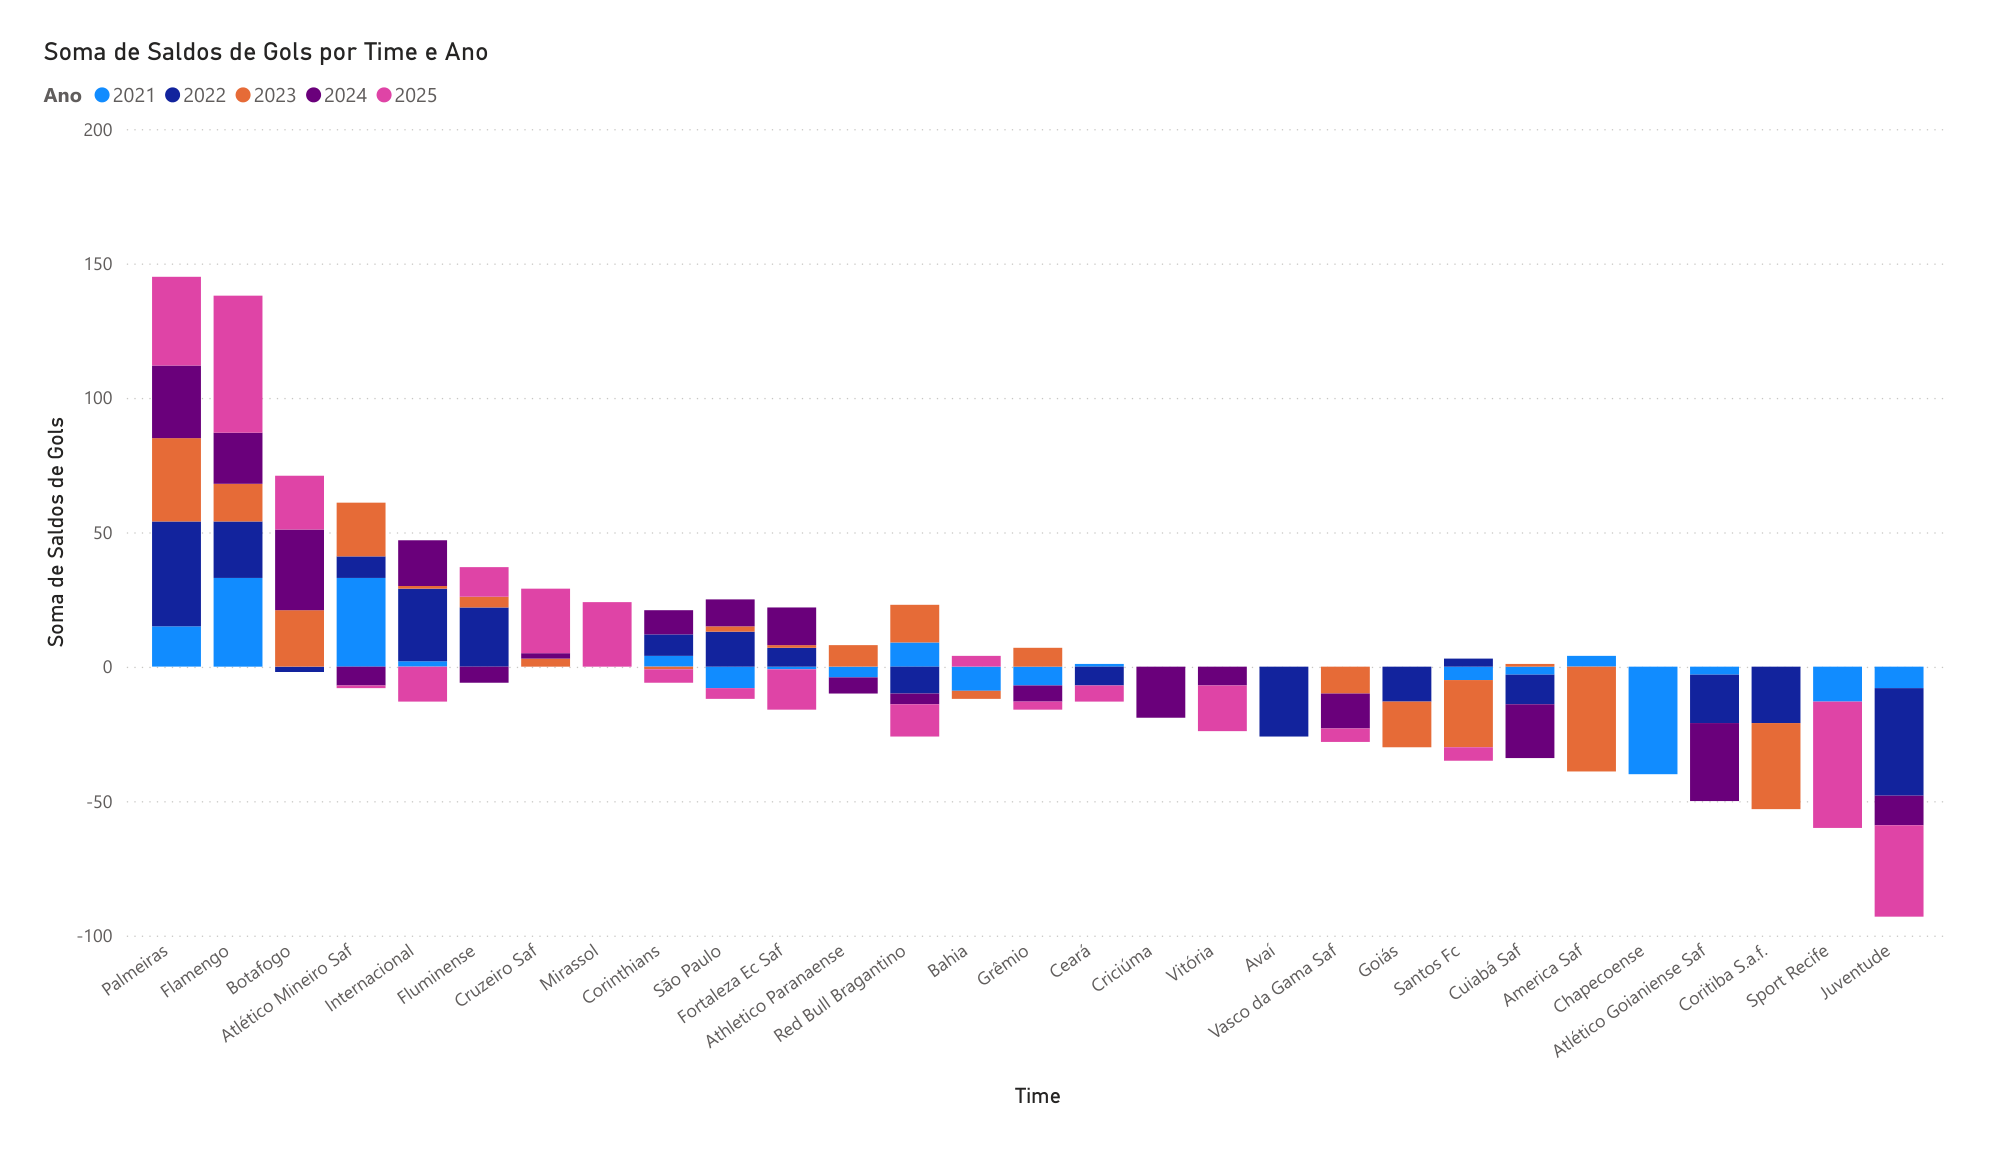

Time (Club) x Cartões Amarelos (Yellow Cards) x Ano (Season):


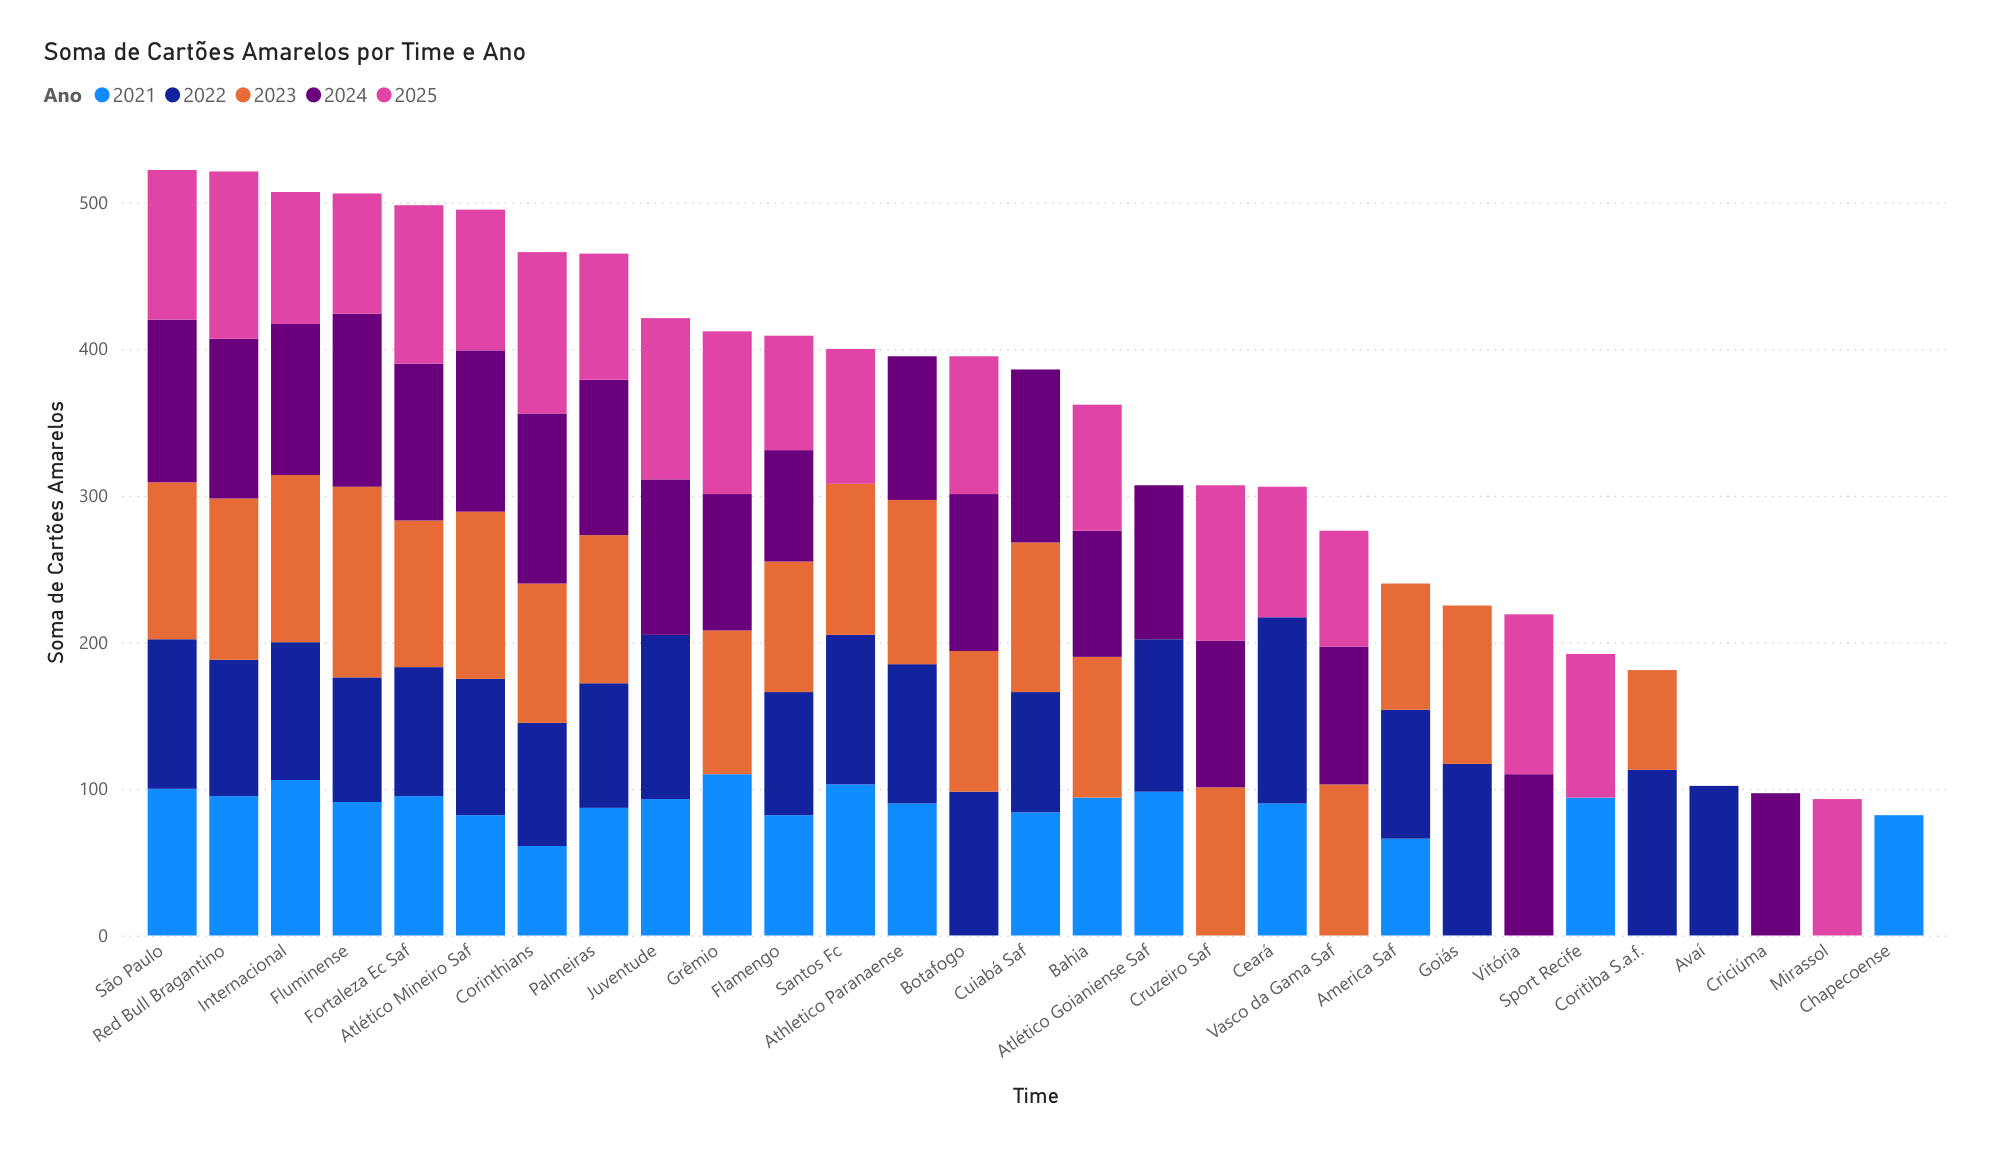

Time (Club) x Cartões Vermelhos (Red Cards) x Ano (Season):


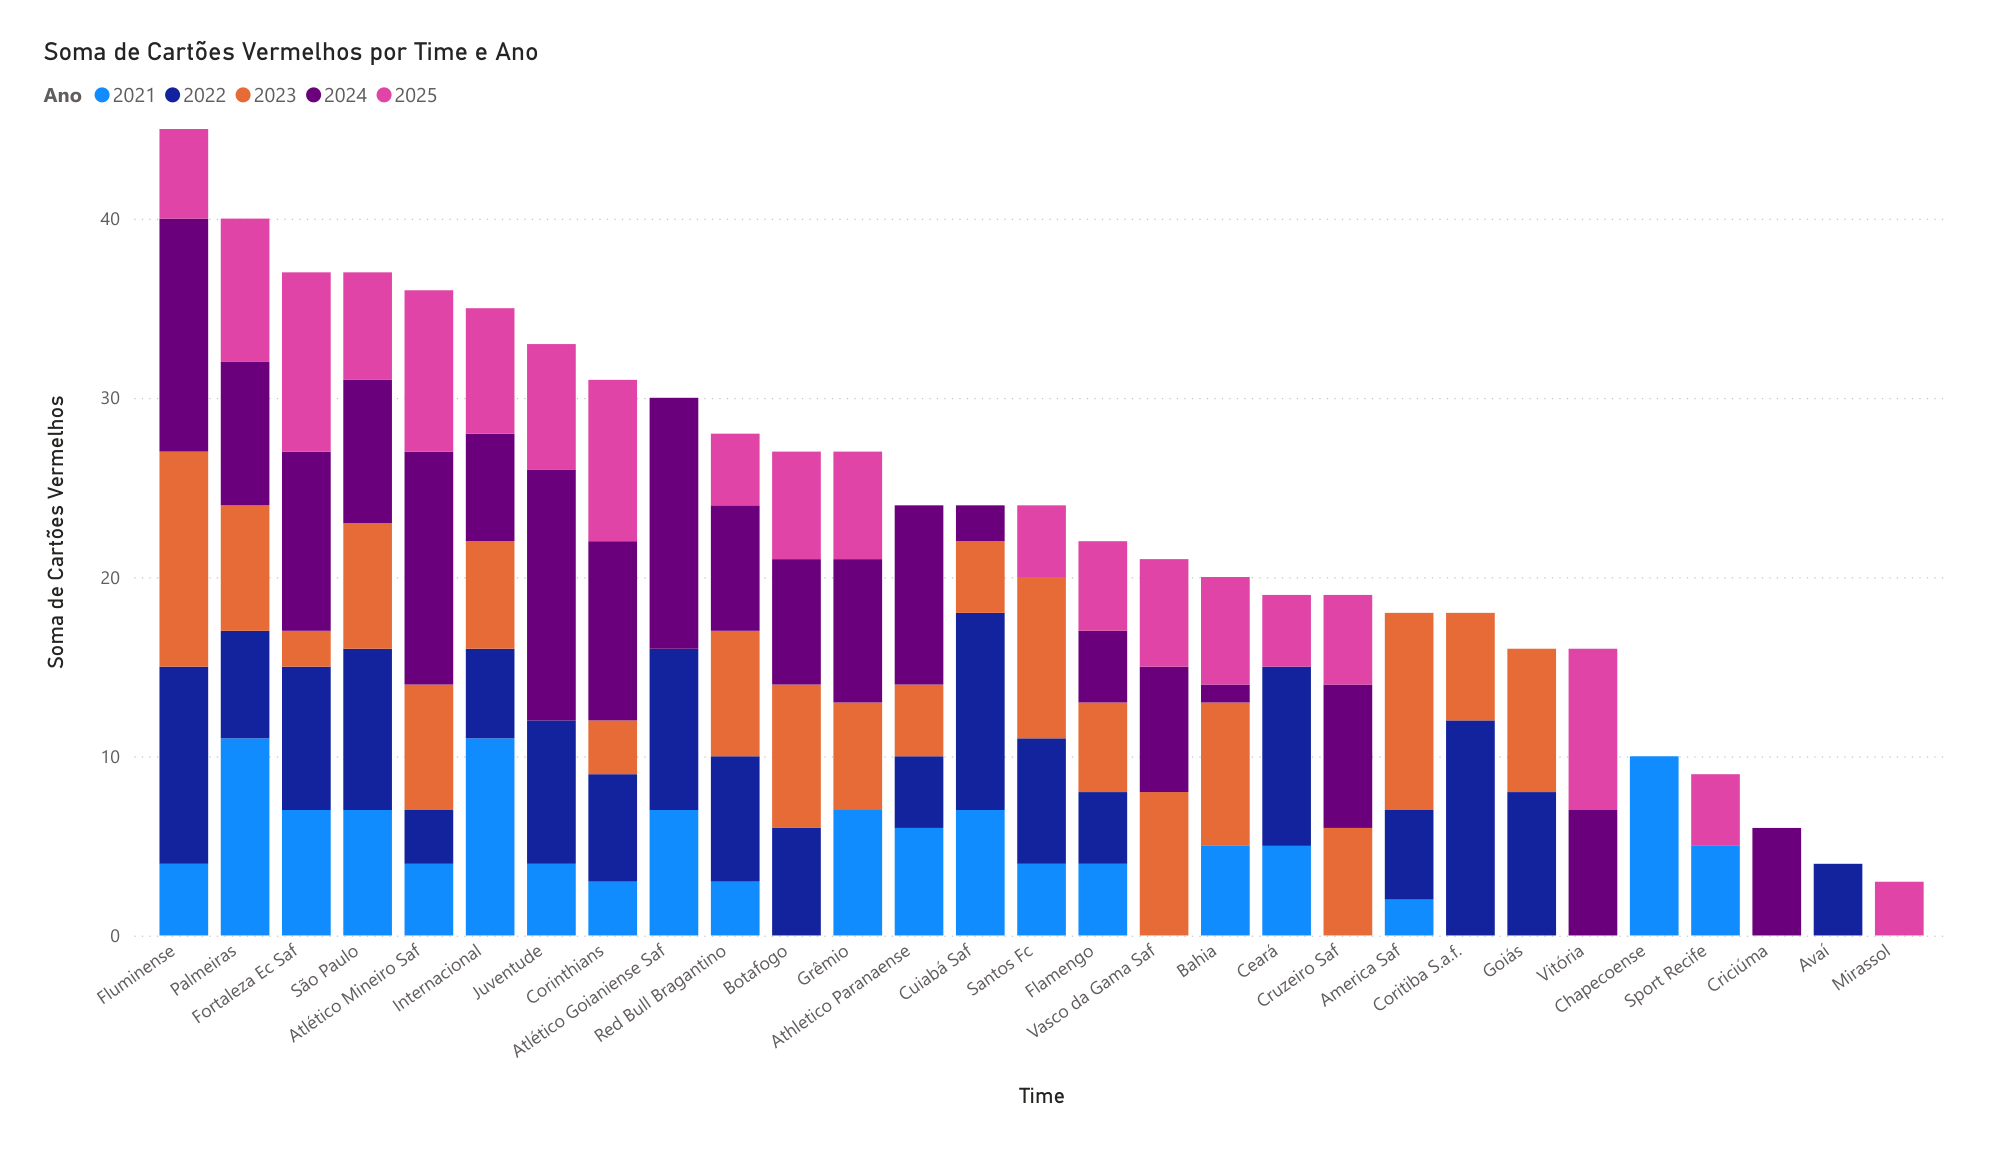

Time (Club) x Aproveitamento (Win %) x Ano (Season):


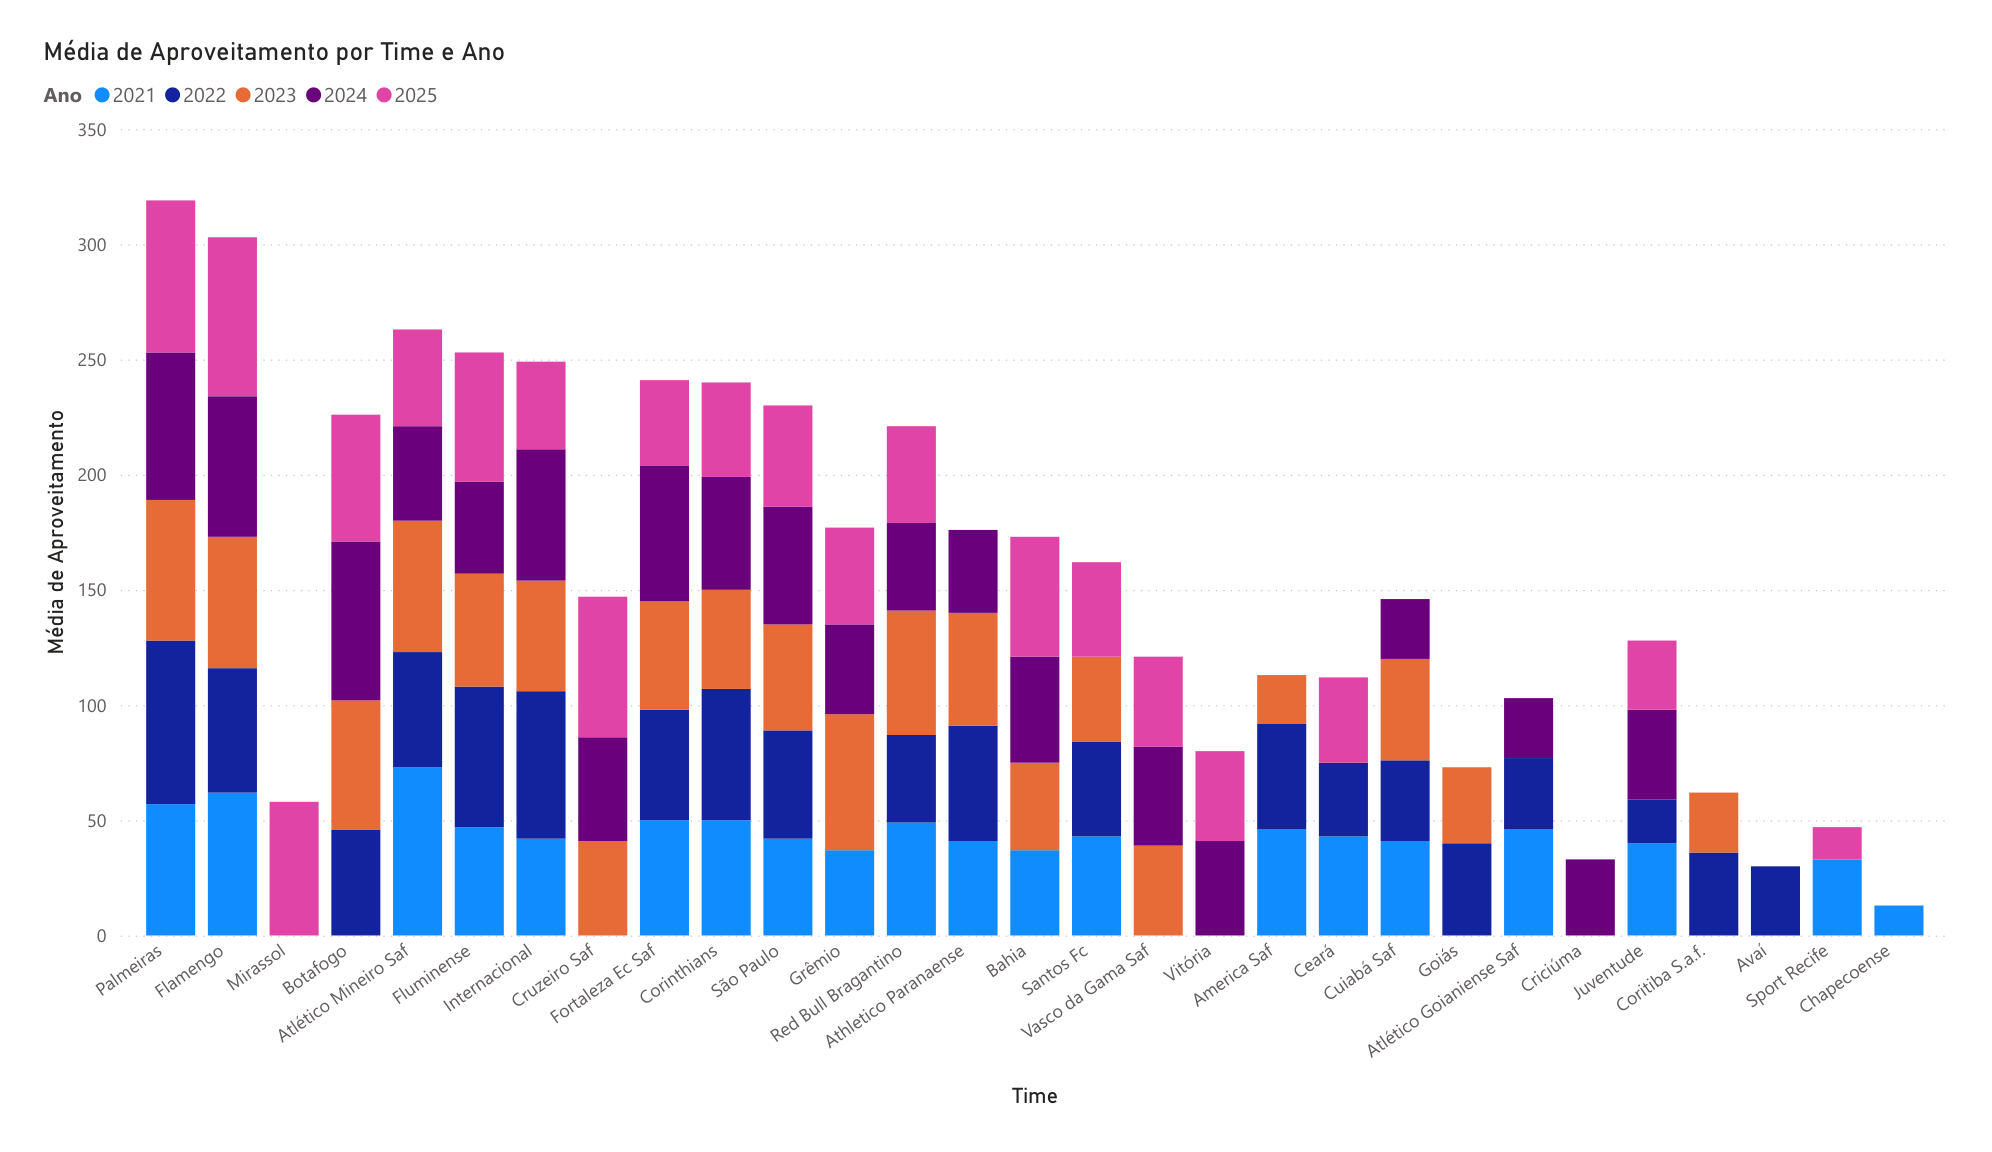

In [6]:
print("\n")
cols = ['Classificação (Standings)', 'Pontos (Points)', 'Jogos (Played)', 'Vitórias (Wins)', 'Empates (Draws)', 'Derrotas (Losses)', 'Gols Prós (Goals For)', 'Gols Contras (Goals Against)', 'Saldo de gols (Goal Difference)', 'Cartões Amarelos (Yellow Cards)', 'Cartões Vermelhos (Red Cards)', 'Aproveitamento (Win %)']
def pdf_to_img(pdf):
    doc = fitz.open(pdf)

    for i in range(len(doc)):
        page = doc.load_page(i)
        matriz = fitz.Matrix(2, 2)
        pix = page.get_pixmap(matrix=matriz)
        img_data = pix.tobytes("png")
        print(f"Time (Club) x {cols[i]} x Ano (Season):")
        display(Image(data=img_data))
    
    doc.close()

pdf_to_img("../../powerbi/brazilian_championship_seriesa.pdf")

In these charts, the goal was to analyze the relationship between Team + Season and the remaining columns. In short, I obtained the following insights:
- There is a clear hegemony between Palmeiras and Flamengo; both lead the statistics for Standings, Points, Played, Wins, Goals For, Goal Difference, and Win %, with Palmeiras leading six (6) out of these seven (7) categories!
- Fluminense and Atlético Mineiro stand out, trailing only Palmeiras and Flamengo in Standings, Points, Played, and Wins, with Atlético Mineiro ahead of Fluminense in all of them.
- Certain teams, such as Botafogo (the only team that played only four (4) out of the five (5) championships and became champion), Corinthians, Internacional, São Paulo, and Fortaleza (despite being relegated in 2025), consistently appear at the top of several key categories, such as Standings, Points, Played, Wins, Goals For, Goal Difference, and Win %. Botafogo, for instance, did not compete in every championship but remained positively consistent.

Notes:
- The Yellow Cards and Red Cards columns revealed absolutely nothing, which was expected; league placement does not imply having more or fewer cards.
- The Draws, Losses, and Goals Against columns were not as significant as those mentioned in the previous points. However, they primarily highlight the consistency of Palmeiras and Flamengo, which appear well below the others in these categories, with Palmeiras consistently lower than Flamengo.
- It is important to emphasize that many teams played more matches than others. For example, Mirassol appearing third in the Win % column does not indicate they are better than the others, as they simply performed well in the ONLY championship they played. Similarly, Fluminense, Palmeiras, and Atlético Mineiro appearing in high positions for Red Cards should be disregarded.